## 1) SINDy in Ground Truth Coordinates z
### 1.1) Simulation

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import Lasso
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [4]:
def pendulum_rhs(zt, dzt, coefficients, terms):
    zt = np.array(zt)
    dzt = np.asarray(dzt)
    
    theta = np.stack([term(zt,dzt) for term in terms], axis = -1)
    
    return theta @ coefficients

def pendulum_ode_step(y, t, coefficients, terms):
    z,dz = y
    ddz = pendulum_rhs(z,dz,coefficients, terms)
    return [dz, ddz]

def simulate_pendulum(z0, dz0, coefficients, terms, T, dt):
    t = np.arange(T) * dt
    y0 = [z0, dz0]
    
    sol = odeint(pendulum_ode_step, y0, t, args = (coefficients, terms))
    z = sol[:,0]
    dz = sol[:,1]
    ddz = pendulum_rhs(z, dz, coefficients, terms)
    
    return z, dz, ddz

def create_pendulum_data(z0_min, z0_max, dz0_min, dz0_max, coefficients, terms, T,
                        dt, N, embedding = None, rejection = True):
    
    z_list, dz_list, ddz_list = [],[],[]

    i = 0
    while i < N:
        z0 = np.random.uniform(z0_min, z0_max)
        dz0 = np.random.uniform(dz0_min, dz0_max)
        
        
        if rejection:
            energy = abs(0.5 * dz0**2 - np.cos(z0))
            if energy > 0.99:
                continue
        
        
        z, dz, ddz = simulate_pendulum(z0, dz0, coefficients, terms, T, dt)
        z_list.append(z)
        dz_list.append(dz)
        ddz_list.append(ddz)
        
        i+=1
        
    z = np.concatenate(z_list)
    dz = np.concatenate(dz_list)
    ddz = np.concatenate(ddz_list)
    
    if embedding is not None:
        return embedding(z, dz, ddz)
        
    return z, dz, ddz
    

In [5]:
terms = [
    lambda z, dz: np.ones_like(z),
    lambda z, dz: z,
    lambda z, dz: dz,
    lambda z, dz: np.sin(z),
    lambda z, dz: z ** 2,
    lambda z, dz: z * dz,
    lambda z, dz: dz ** 2,
    lambda z, dz: dz * np.sin(z),
    lambda z, dz: np.sin(z) ** 2,
    lambda z, dz: z * np.sin(z),
]

term_names = [
    "1", "z", "dz", "sin(z)", "z^2",
    "z*dz", "dz^2", "dz*sin(z)", "sin(z)^2", "z*sin(z)"
]

coefficients = np.zeros(len(terms))
coefficients[3] = -1.0

In [6]:
N = 100
T = 50
dt = 0.02

z, dz, ddz = create_pendulum_data(
    z0_min = -np.pi, z0_max = np.pi,
    dz0_min = -2.1, dz0_max = 2.1,
    coefficients = coefficients, terms = terms,
    T = T, dt = dt, N = N
)

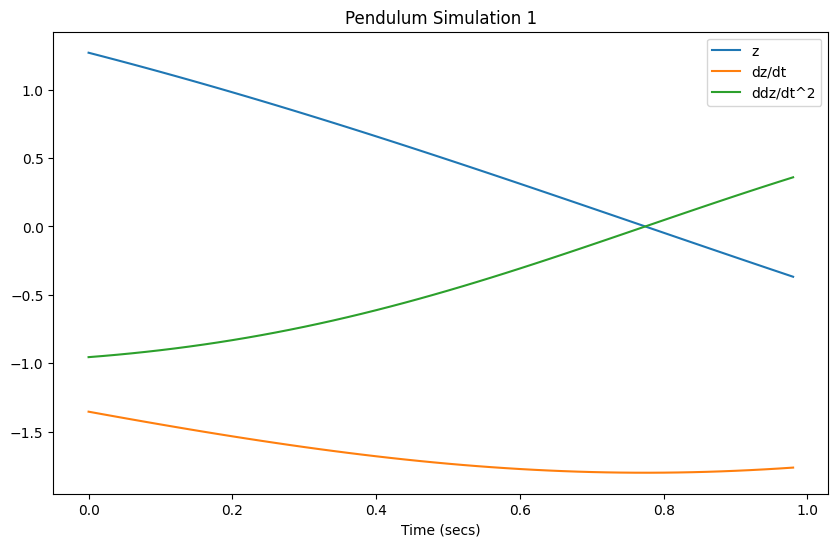

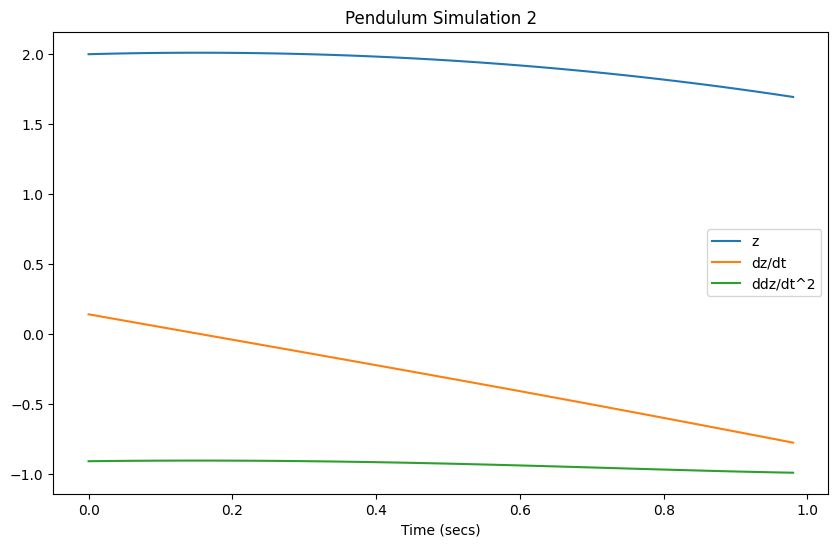

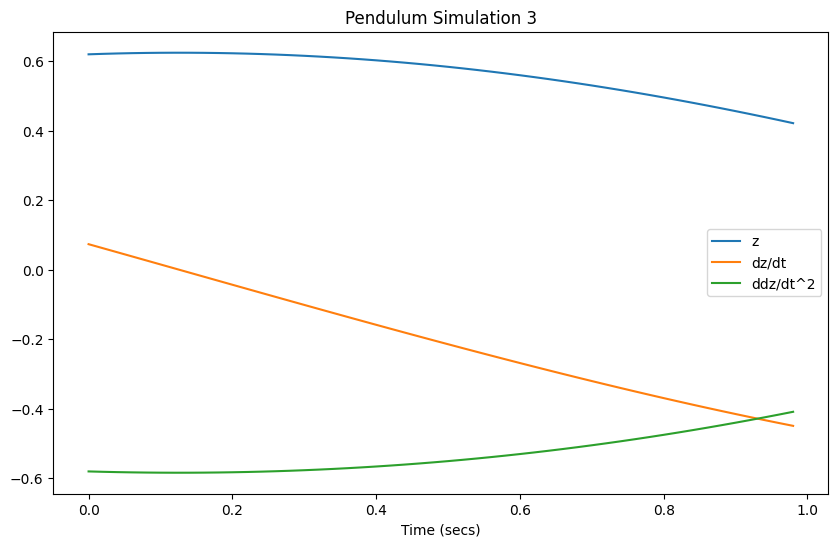

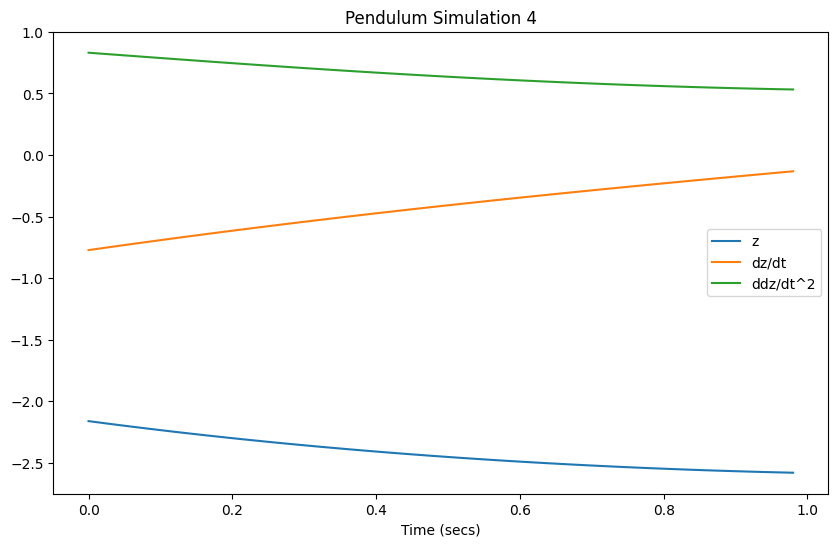

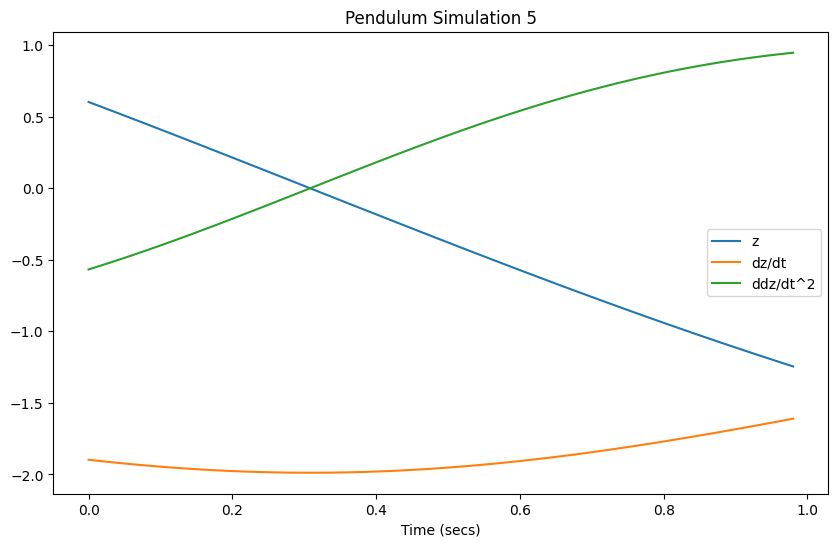

In [7]:
z_reshaped = z.reshape(N,T)
dz_reshaped = dz.reshape(N,T)
ddz_reshaped = ddz.reshape(N,T)
t = np.arange(T) * dt

for i in range(5):
    plt.figure(figsize = (10,6))
    plt.plot(t, z_reshaped[i], label = "z")
    plt.plot(t, dz_reshaped[i], label = "dz/dt")
    plt.plot(t, ddz_reshaped[i], label = "ddz/dt^2")
    
    plt.xlabel("Time (secs)")
    plt.title(f"Pendulum Simulation {i+1}")
    plt.legend()
    plt.show()



### 1.2 & 1.3)

In [8]:
from sklearn.linear_model import Lasso

def sindy_lasso(z, dz, ddz, terms, alpha = 1e-4):
    theta = np.column_stack([term(z,dz) for term in terms])
    lasso = Lasso(alpha = alpha, fit_intercept = False, max_iter = 10000)
    lasso.fit(theta, ddz)
    
    Xi = lasso.coef_.reshape(-1, 1)
    return Xi, lasso

Xi_lasso, lasso_model = sindy_lasso(z,dz, ddz, terms)

class SINDy(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.Xi = nn.Parameter(torch.zeros(dim, 1))
        self.register_buffer('mask', torch.ones(dim, 1, dtype = torch.bool))
        
    def forward(self, z, dz):
        theta = torch.stack([
            torch.ones_like(z), z, dz, torch.sin(z), z**2, z*dz, z*torch.sin(z), dz**2, 
                                dz*torch.sin(z), torch.sin(z) ** 2], dim = -1).squeeze(1)
        return theta @ (self.Xi * self.mask.float())
    
    def sequential_threshold(self, a):
        small = torch.abs(self.Xi) <a
        self.Xi.data[small] = 0.0
        self.mask[small] = False
        
    def ptat_threshold(self, b = 0.002, P = 100):
        Xi = self.Xi.detach()
        abs_diff = torch.abs(Xi - self.Xi_prev)
        self.Eb = torch.where(abs_diff > b, torch.ternsor(self.epoch, device = Xi.device), self.Eb)
        recent_b = (self.epoch - self.Eb) < P
        self.mask &= recent_b
        self.Xi_prev = Xi.clone()
        self.epoch +=1 

        
    def freeze_inactive_terms(self):
        self.Xi.register_hook(lambda l: l * self.mask.float())
        
    def patient_thresholding(self, history, threshold_a = 0.1, threshold_b = 0.002, patience = 100):
        num = len(history)
        dim = history[0].shape[0]
        
        mask = torch.ones(dim, 1, dtype = torch.bool)
        prev_Xi = torch.zeros_like(history[0])
        a = torch.zeros(dim, 1, dtype = torch.long)
        b = torch.zeros(dim, 1, dtype = torch.long)
        
        for e in range(num):
            Xi = history[e]
            abs_Xi = torch.abs(Xi)
            abs_diff = torch.abs(Xi - prev_Xi)
            
            a = torch.where(abs_Xi > threshold_a, torch.tensor(e), a)
            b = torch.where(abs_diff > threshold_b, torch.tensor(e), b)
            recent_a=(e-a)< patience
            recent_b=(e-b)< patience
            keep_mask=recent_a | recent_b
            mask = mask & keep_mask
            prev_Xi = Xi.clone()
        
        return mask
        

In [9]:
def train_SINDy( model, z, dz, ddz, terms, lr = 1e-2, epochs = 2000, thresholding = None, 
                a = 1e-2, b = 1e-3, S = 100, P= 200):
    
    z= torch.tensor(z,dtype=torch.float32).unsqueeze(1)
    dz= torch.tensor(dz,dtype=torch.float32).unsqueeze(1)
    ddz=torch.tensor(ddz,dtype=torch.float32).unsqueeze(1)
    
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    losses = []
    Xi_hist = []
    
    if thresholding == "patient":
        Xi_prev = torch.zeros_like(model.Xi)
        Ea = torch.zeros_like(model.Xi, dtype = torch.long)
        Eb = torch.zeros_like(model.Xi, dtype = torch.long)
    
    for e in range(epochs):
        optimizer.zero_grad()
        pred = model(z, dz)
        loss = ((pred-ddz) ** 2).mean()
        loss.backward()
        optimizer.step()
        
        if thresholding == "sequential" and e % S == 0:
            small = torch.abs(model.Xi) < a
            model.Xi.data[small] = 0.0
            model.mask[small] = False
        elif thresholding == "patient":
            Ea[torch.abs(model.Xi) > a] = e
            Eb[torch.abs(model.Xi - Xi_prev) > b] = e
            
            keep = ((e - Ea) < P) | ((e-Eb) < P)
            model.mask &= keep
            Xi_prev = model.Xi.detach().clone()
        
        losses.append(loss.item())
        Xi_hist.append(model.Xi.detach().cpu().numpy().copy())
        
    return losses, np.array(Xi_hist)